This notebook is to set up the training of geneid with different type of training set:
- multi-single enxon (100, 500, 1000, 2000, 5000)
- only multiexon (100, 500, 1000, 2000, 5000) 

The training will be perfomed in:
- Drosophila_melanogaster (best annotation)
- Drosophila_virilis (distant from Dmel)
- Musca_domestica (outgroup)

These are the steps to follow:
1. keep only longest isoform (agat)
2. create a new gff with exons features only and gene identifier in the last column `../scripts/sample_CDS.sh` 
3. remove overlapping and create a gff that contains only exons 
4. create a multi-exon only gff
5. sample from all exons and from onlt multi-exo

### Counclusions
- No need to exclude monoexonic genes
- 1k and 2k provide same busco completness but less running time

In [1]:
from collections import Counter

In [2]:
training_data = '/users/rg/fzanarello/projects/geneid-bg/data/training_data/'

In [3]:
species  = ['Drosophila_melanogaster.7227',
            'Drosophila_virilis.7244',
            'Musca_domestica.7370']

# Create training set

### Create titration folder and add reference

In [4]:
for s in species:
    species_folder = f'{training_data}{s}'
    # ! mkdir -p $species_folder/titration
    ref = ! ls /no_backup/rg/references/species/$s/*/*.gff
    ref = ref[0]
    # ! ln -s $ref $species_folder/titration/reference.gff

### Get only longest isoform

In [5]:
for s in species:
    ref = f'{training_data}{s}/titration/reference.gff'
    target = f'{training_data}{s}/titration/reference_long.gff'
    # ! singularity run /software/rg/images/agat_1.4.2--943d1a3a7115147b.sif agat_sp_keep_longest_isoform.pl -gff $ref -o $target

### Get overlapping genes

In [6]:
for s in species:
    input_gff = f'{training_data}{s}/titration/reference_long.gff'
    genes_list = f'{training_data}{s}/titration/genes_to_remove.txt'
    ! bash ../scripts/get_overlapping_genes.sh $input_gff $genes_list

Overlapping protein-coding gene list saved to: /users/rg/fzanarello/projects/geneid-bg/data/training_data/Drosophila_melanogaster.7227/titration/genes_to_remove.txt
Overlapping protein-coding gene list saved to: /users/rg/fzanarello/projects/geneid-bg/data/training_data/Drosophila_virilis.7244/titration/genes_to_remove.txt
Overlapping protein-coding gene list saved to: /users/rg/fzanarello/projects/geneid-bg/data/training_data/Musca_domestica.7370/titration/genes_to_remove.txt


### Remove genes from annotation

In [9]:
for s in species:
    input_gff = f'{training_data}{s}/titration/reference_long.gff'
    genes_list = f'{training_data}{s}/titration/genes_to_remove.txt'
    out_gff = f'{training_data}{s}/titration/reference_long_clean.gff'
    ! singularity run /software/rg/images/agat_1.4.2--943d1a3a7115147b.sif agat_sp_filter_feature_from_kill_list.pl --gff $input_gff --kill_list $genes_list  --output $out_gff


 ------------------------------------------------------------------------------
|   Another GFF Analysis Toolkit (AGAT) - Version: v1.4.1                      |
|   https://github.com/NBISweden/AGAT                                          |
|   National Bioinformatics Infrastructure Sweden (NBIS) - www.nbis.se         |
 ------------------------------------------------------------------------------
=> Using standard /opt/conda/lib/perl5/site_perl/auto/share/dist/AGAT/agat_config.yaml config file
03/21/2025 at 10h06m09s
usage: /opt/conda/bin/agat_sp_filter_feature_from_kill_list.pl --gff /users/rg/fzanarello/projects/geneid-bg/data/training_data/Drosophila_melanogaster.7227/titration/reference_long.gff --kill_list /users/rg/fzanarello/projects/geneid-bg/data/training_data/Drosophila_melanogaster.7227/titration/genes_to_remove.txt --output /users/rg/fzanarello/projects/geneid-bg/data/training_data/Drosophila_melanogaster.7227/titration/reference_long_clean.gff
We will discard all featu

### Generate a only CDS gff

In [10]:
for s in species:
    input_gff = f'{training_data}{s}/titration/reference_long_clean.gff'
    output_gff = f'{training_data}{s}/titration/all_CDS_all.gff'
    ! bash ../scripts/get_CDS.sh $input_gff > $output_gff

### Check number of avilable genes for training

In [11]:
for s in species:
    input_gff = f'{training_data}{s}/titration/all_CDS_all.gff'
    genes = ! cut -f 9 $input_gff

    single = 0
    multi = 0
    
    d = dict(Counter(genes))
    
    for k in d:
        if d[k] == 1:
            single += 1
        if d[k] > 1:
            multi += 1

    print (s)
    print ('mono', single)
    print ('multi', multi)
    print ()


Drosophila_melanogaster.7227
mono 1688
multi 6531

Drosophila_virilis.7244
mono 1597
multi 7049

Musca_domestica.7370
mono 2109
multi 11329



### sample genes for training

In [12]:
for s in species:
    print ()
    print (s)
    input_gff = f'{training_data}{s}/titration/all_CDS_all.gff'
    
    for size in ['100', '200', '500', '1000', '2000', '5000']:
        print (size)
        sample_name_all = f'{training_data}{s}/titration/all_CDS_sample{size}.gff'
        sample_name_multi = f'{training_data}{s}/titration/multiexon_CDS_sample{size}.gff'
        
        ! bash ../scripts/../scripts/sample_CDS.sh $input_gff $size > $sample_name_all
        ! bash ../scripts/../scripts/sample_CDS_multiexonsONLY.sh $input_gff $size > $sample_name_multi


Drosophila_melanogaster.7227
100
200
500
1000
2000
5000

Drosophila_virilis.7244
100
200
500
1000
2000
5000

Musca_domestica.7370
100
200
500
1000
2000
5000


### prepare training scripts

In [15]:
with open('../job_commands/drosophila_titration.txt', 'w') as out:

    ! mkdir -p /users/rg/fzanarello/projects/geneid-bg/results/titration_drosophila
    
    for s in species:
        print (s)
        ! mkdir -p /users/rg/fzanarello/projects/geneid-bg/results/titration_drosophila/$s

        reference_genome = ! realpath /users/rg/fzanarello/projects/geneid-bg/data/training_data/$s/CLEAN*.fna
        reference_genome = reference_genome[0]
    
        all_CDS = ! ls $training_data/$s/titration/all_CDS*
        multi_CDS = ! ls $training_data/$s/titration/multiexon_CDS*
        input_list = all_CDS + multi_CDS
    
        for i in input_list:
            print (i)
            input_file = i
            input_type = i.split('/')[-1].split('_')[0]
            input_size = i.split('/')[-1].split('_')[2].replace('.gff','')
            sample_name = f'{s.replace('.','_')}_{input_size}_{input_type}'

            res_folder = f'/users/rg/fzanarello/projects/geneid-bg/results/titration_drosophila/{s}/{sample_name}/'
            
            geneidtrainer_command = (
                                        f"time singularity run "
                                        f"/software/rg/images/geneidtrainerdocker.sif "
                                        f"/scripts_geneid/geneidTRAINer4docker.pl "
                                        f"-species {sample_name} "
                                        f"-gff {input_file} "
                                        f"-fastas {reference_genome} "
                                        f"-results {res_folder} "
                                        f"-reduced no"
                                    )
            out.write(geneidtrainer_command+'\n')

Drosophila_melanogaster.7227
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_all.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample1000.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample100.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample2000.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample200.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample5000.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/all_CDS_sample500.gff
/users/rg/fzanarello/projects/geneid-bg/data/training_data//Drosophila_melanogaster.7227/titration/multiexon_CDS_sample1000.gff

### rerun some dataset for OOM

In [1]:
failed_commands = ! for i in $(grep -l 'OOM Killed' /nfs/scratch01/rg/fzanarello/logs/titration_mel_vir_dom_6639161_*err); do grep 'COMMAND=' $i ; done

In [3]:
# failed_commands

In [23]:
with open('../job_commands/redo_titration_morememory.txt', 'w') as out:
    for f in failed_commands:
        line = f.split('\'')[1]
        out.write(line+'\n')

### some datasets did not optimized

In [ ]:
titration_mel_vir_dom_6639161_15.err Drosophila_virilis_7244_all_all
titration_mel_vir_dom_6639161_0.err Drosophila_melanogaster_7227_all_all

titration_mel_vir_dom_6639161_16.err Drosophila_virilis_7244_sample10000_all
titration_mel_vir_dom_6639161_1.err Drosophila_melanogaster_7227_sample10000_all

titration_mel_vir_dom_6639161_23.err Drosophila_virilis_7244_sample10000_multiexon
titration_mel_vir_dom_6639161_8.err Drosophila_melanogaster_7227_sample10000_multiexon

# Predict

In [5]:
with open('../job_commands/titration_preds.txt', 'w') as out:
    for s in species:
        folders = ! ls -d ../results/titration_drosophila/$s/*/
        print (s)
        for f in folders:
            sample = f.split('/')[-2]
            print (sample)
            ! mkdir -p $f/predictions
            
            param_file = ! realpath $f/*.optimized.param
            param_file = param_file[0]
            ! ln -s $param_file $f/predictions
            
            reference = ! realpath ../results/drosophila_phylo/$s/*fna
            reference = reference[0]
            ! ln -s $reference $f/predictions

            out_folder = ! realpath $f/predictions
            out_folder = out_folder[0]
            models = f'{out_folder}/{sample}.gff3'

            command = f'time geneid -3P {param_file} {reference} > {models}'
            out.write(command + '\n')
        

Drosophila_melanogaster.7227
Drosophila_melanogaster_7227_sample1000_all
Drosophila_melanogaster_7227_sample1000_multiexon
Drosophila_melanogaster_7227_sample100_all
Drosophila_melanogaster_7227_sample100_multiexon
Drosophila_melanogaster_7227_sample2000_all
Drosophila_melanogaster_7227_sample2000_multiexon
Drosophila_melanogaster_7227_sample200_all
Drosophila_melanogaster_7227_sample200_multiexon
Drosophila_melanogaster_7227_sample5000_all
Drosophila_melanogaster_7227_sample5000_multiexon
Drosophila_melanogaster_7227_sample500_all
Drosophila_melanogaster_7227_sample500_multiexon
Drosophila_virilis.7244
Drosophila_virilis_7244_sample1000_all
Drosophila_virilis_7244_sample1000_multiexon
Drosophila_virilis_7244_sample100_all
Drosophila_virilis_7244_sample100_multiexon
Drosophila_virilis_7244_sample2000_all
Drosophila_virilis_7244_sample2000_multiexon
Drosophila_virilis_7244_sample200_all
Drosophila_virilis_7244_sample200_multiexon
Drosophila_virilis_7244_sample5000_all
Drosophila_virilis

# Comapare

### run compann

In [29]:
# link annotations and references
species = ! ls ../results/titration_drosophila/

for s in species:

    train_sets = ! find ../results/titration_drosophila/$s -type d -maxdepth 1 -mindepth 1
    
    ref_genome = !  realpath ../drosophila_data/$s/*/*.fna
    ref_genome = ref_genome[0]
    
    ref_ann = !  realpath ../drosophila_data/$s/*/*.gff
    ref_ann = ref_ann[0]

    s_id = s.replace('.','_')


    for train_set in train_sets:

        ! mkdir -p $train_set/compann/input
        ! mkdir -p $train_set/compann/output

        # ! ln -s $ref_genome $train_set/compann/input/
        # ! ln -s $ref_ann $train_set/compann/input/RefSeq_$s_id'.gff'

        train_set_ann = ! find $train_set/predictions/*.gff3
        train_set_ann = train_set_ann[0]
        train_set_ann = ! realpath $train_set_ann
        train_set_ann = train_set_ann[0]       
        train_set_name = ! basename $train_set_ann .gff3
        train_set_name = f'geneid{train_set_name[0].split('_')[-2]}{train_set_name[0].split('_')[-1]}_{s_id}.gff3'       
        # ! ln -s $train_set_ann $train_set/compann/input/$train_set_name


In [31]:
species = ! ls ../results/titration_drosophila/

with open('../job_commands/titration_compann.sh', 'w') as out:
    
    for s in species:

        train_sets = ! find ../results/titration_drosophila/$s -type d -maxdepth 1 -mindepth 1

        for train_set in train_sets:

            work_folder = ! realpath $train_set/compann*
            work_folder = work_folder[0]
            
            ref = ! ! realpath $work_folder/input/*.fna
            ref = ref[0]
            
            input_folder = ! realpath $work_folder/input/
            input_folder = input_folder[0]
            
            output_folder = ! realpath $work_folder/output/
            output_folder = output_folder[0]
            
            cd_command = f'cd {work_folder}'
            nfx_command = f"nextflow run -resume /users/rg/fzanarello/pipelines/compann-nf/main.nf -profile slurm  --gff_folder {input_folder} --outputFolder {output_folder} --ref {ref} --lineage diptera_odb10"
            out.write(cd_command + ' && ' + nfx_command + '\n')

### training times

In [1]:
import re
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [32]:
def extract_training_info(log_file):
    """
    Extracts model name from the "TRAINING OF" line and total runtime (user + sys) from the log file.

    :param log_file: Path to the log file.
    :return: Dictionary with model name as the key and total runtime (in seconds) as the value.
    """
    training_pattern = re.compile(r'TRAINING OF ([\w\d_]+) FOR GENEID PREDICTION')
    user_time_pattern = re.compile(r'user\s+(\d+)m([\d.]+)s')
    sys_time_pattern = re.compile(r'sys\s+(\d+)m([\d.]+)s')

    model_name = None
    user_time = 0
    sys_time = 0

    with open(log_file, 'r', encoding='utf-8') as file:
        for line in file:
            # Extract model name from "TRAINING OF" line
            training_match = training_pattern.search(line)
            if training_match:
                model_name = training_match.group(1)

            # Extract user time
            user_match = user_time_pattern.search(line)
            if user_match:
                user_time = int(user_match.group(1)) * 60 + float(user_match.group(2))

            # Extract sys time
            sys_match = sys_time_pattern.search(line)
            if sys_match:
                sys_time = int(sys_match.group(1)) * 60 + float(sys_match.group(2))

    if model_name and (user_time or sys_time):
        total_time = user_time + sys_time
        result = {'model': model_name,
                  'sec': round(total_time, 3),
                  'min': round(total_time / 60, 3)}
        return result
    else:
        print(f"Could not extract model name or runtime from {log_file}.")
        result = {'model': model_name,
                  'sec': np.nan,
                  'min': np.nan}
        return result

In [34]:
df = pd.DataFrame()
jobs = ! ls /nfs/scratch01/rg/fzanarello/logs/redo_dro_titrat_8664037*err
jobs_failed = ! ls /nfs/scratch01/rg/fzanarello/logs/dro_titr_failed_8666416*err

for i in jobs + jobs_failed:
    d = extract_training_info(i)
    df = pd.concat([df, pd.DataFrame([d])], ignore_index=True)

df = df.dropna()
df['species'] = df['model'].apply(lambda x: '_'.join(x.split('_')[:2]) if isinstance(x, str) else x)
df['size'] = df['model'].apply(lambda x: x.split('_')[-2] if isinstance(x, str) else x)
df['set'] = df['model'].apply(lambda x: x.split('_')[-1] if isinstance(x, str) else x)

Could not extract model name or runtime from /nfs/scratch01/rg/fzanarello/logs/redo_dro_titrat_8664037_13.err.
Could not extract model name or runtime from /nfs/scratch01/rg/fzanarello/logs/redo_dro_titrat_8664037_26.err.
Could not extract model name or runtime from /nfs/scratch01/rg/fzanarello/logs/redo_dro_titrat_8664037_31.err.
Could not extract model name or runtime from /nfs/scratch01/rg/fzanarello/logs/redo_dro_titrat_8664037_37.err.


In [35]:
df

,model,sec,min,species,size,set
0,Drosophila_melanogaster_7227_all_all,4313.467,71.891,Drosophila_melanogaster,all,all
1,Drosophila_melanogaster_7227_sample200_multiexon,159.127,2.652,Drosophila_melanogaster,sample200,multiexon
2,Drosophila_melanogaster_7227_sample5000_multiexon,3240.971,54.016,Drosophila_melanogaster,sample5000,multiexon
3,Drosophila_melanogaster_7227_sample500_multiexon,416.376,6.940,Drosophila_melanogaster,sample500,multiexon
5,Drosophila_virilis_7244_sample1000_all,712.539,11.876,Drosophila_virilis,sample1000,all
6,Drosophila_virilis_7244_sample100_all,80.380,1.340,Drosophila_virilis,sample100,all
7,Drosophila_virilis_7244_sample2000_all,1551.080,25.851,Drosophila_virilis,sample2000,all
8,Drosophila_virilis_7244_sample200_all,147.001,2.450,Drosophila_virilis,sample200,all
9,Drosophila_virilis_7244_sample5000_all,3756.178,62.603,Drosophila_virilis,sample5000,all
10,Drosophila_virilis_7244_sample500_all,497.430,8.290,Drosophila_virilis,sample500,all


In [36]:
df['size'].unique()

array(['all', 'sample200', 'sample5000', 'sample500', 'sample1000',
       'sample100', 'sample2000'], dtype=object)

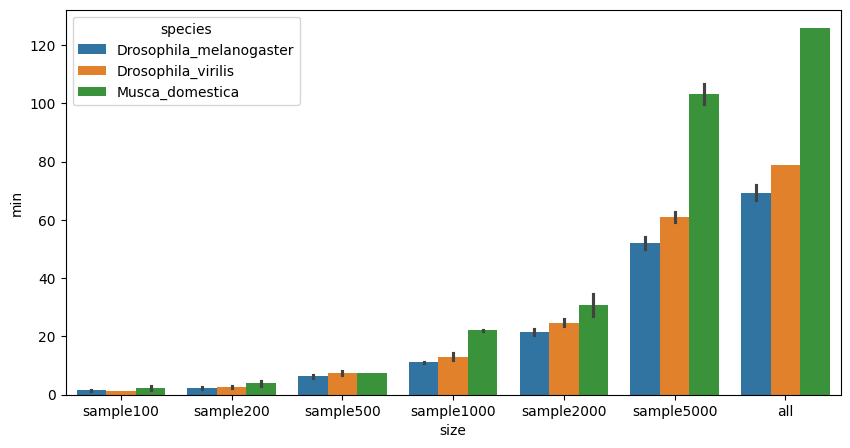

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data = df,
               x = 'size',
               order = ['sample100', 'sample200', 'sample200',
                        'sample500','sample1000', 'sample2000',
                        'sample5000', 'all'],
               y = 'min', 
               hue = 'species',
               ax=ax)
plt.show()

### BUSCO

In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
titration_res_files = ! find ../results/titration_drosophila/*/*/compann/output/BUSCO/ -name 'combined_BUSCO_results.csv'
musca_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Musca_domestica.7370/output/BUSCO/ -name 'combined_BUSCO_results.csv'
dmel_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_melanogaster.7227/output/BUSCO/ -name 'combined_BUSCO_results.csv'
dvir_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_virilis.7244/output/BUSCO/ -name 'combined_BUSCO_results.csv'

In [3]:
busco_res_files = titration_res_files + musca_res_files + dmel_res_files + dvir_res_files

In [4]:
busco_df = pd.DataFrame()
for f in busco_res_files:
    tmp_df = pd.read_csv(f)
    tmp_df.set_index('metric', inplace=True)
    busco_df = pd.concat([busco_df, tmp_df], axis=1)

busco_df = busco_df.loc[:,~busco_df.columns.duplicated()].copy()

In [5]:
cols_to_remove = [
       'BUSCO_geneidDMEL_Musca_domestica_7370_transcripts',
       'BUSCO_geneidSELF_Musca_domestica_7370_transcripts',
       'BUSCO_geneidDMEL_Drosophila_melanogaster_7227_transcripts',
       'BUSCO_geneidSELF_Drosophila_melanogaster_7227_transcripts',
       'BUSCO_geneidDMEL_Drosophila_virilis_7244_transcripts',
       'BUSCO_geneidSELF_Drosophila_virilis_7244_transcripts'
                ]

busco_df = busco_df.drop(columns=cols_to_remove)
busco_df = busco_df.transpose()

In [6]:
def get_program(x):
    if 'RefSeq' in x:
        return 'RefSeq'
    if 'helixer' in x:
        return 'helixer'
    if 'augustus' in x:
        return 'augustus'
    if 'geneid':
        return 'geneid'

In [7]:
def get_species(x):
    species = '_'.join(x.split('_')[-4:-2])
    return species

In [8]:
def get_sample_size(x):
    if 'geneid' in x:
        sample_size = x.split('_')[1].replace('geneidsample','')
        if 'multiexon' in sample_size:
            sample_size = sample_size.replace('multiexon','')
            return sample_size
        else:
            sample_size = sample_size.replace('all','')
            return sample_size
    else:
        return np.nan

In [9]:
def get_sample_type(x):
    if 'multiexon' in x:
        return 'multiexon'
    if 'all' in x:
        return 'all'
    else:
        return np.nan

In [10]:
busco_df['Species'] = busco_df.index.map(get_species)
busco_df['program'] = busco_df.index.map(get_program)
busco_df['training_size'] = busco_df.index.map(get_sample_size)
busco_df['sample_type'] = busco_df.index.map(get_sample_type)

busco_df['Complete percentage'] = pd.to_numeric(busco_df['Complete percentage'])
busco_df['Single copy percentage'] = pd.to_numeric(busco_df['Single copy percentage'])
busco_df['Multi copy percentage'] = pd.to_numeric(busco_df['Multi copy percentage'])
busco_df['Fragmented percentage'] = pd.to_numeric(busco_df['Fragmented percentage'])
busco_df['Missing percentage'] = pd.to_numeric(busco_df['Missing percentage'])

In [11]:
busco_df.columns

Index(['one_line_summary', 'Complete percentage', 'Complete BUSCOs',
       'Single copy percentage', 'Single copy BUSCOs', 'Multi copy percentage',
       'Multi copy BUSCOs', 'Fragmented percentage', 'Fragmented BUSCOs',
       'Missing percentage', 'Missing BUSCOs', 'n_markers', 'avg_identity',
       'domain', 'internal_stop_codon_count', 'internal_stop_codon_percent',
       'name', 'creation_date', 'number_of_buscos', 'number_of_species',
       'Species', 'program', 'training_size', 'sample_type'],
      dtype='object', name='metric')

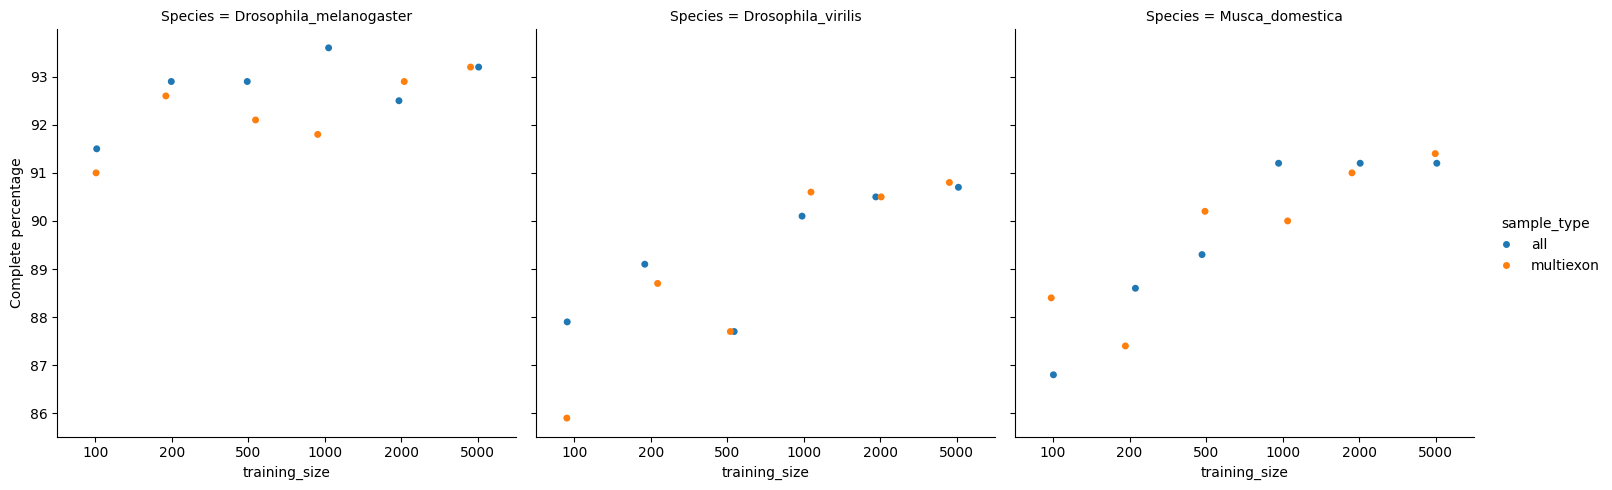

In [12]:
metric = 'Complete percentage'

g = sns.catplot(
    data=busco_df,
    x='training_size',
    y=metric,
    hue = 'sample_type', 
    col = 'Species',
    order= [100, 200, 500, 1000, 2000, 5000],
    )

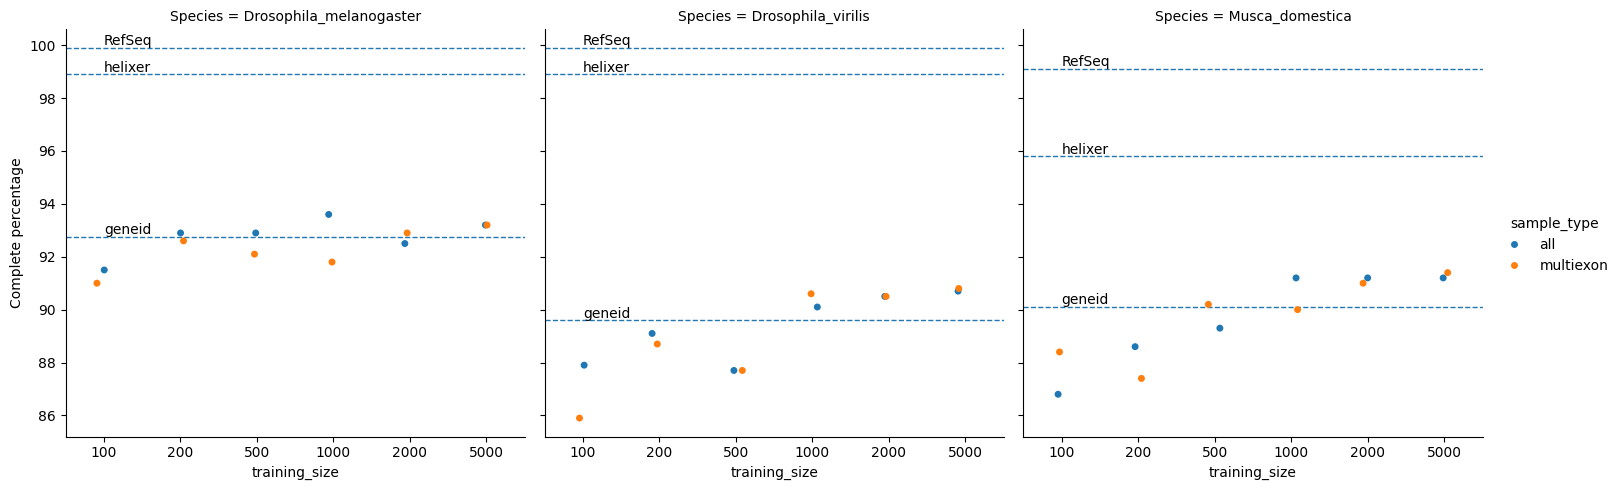

In [13]:
metric = 'Complete percentage'

g = sns.catplot(
    data=busco_df,
    x='training_size',
    y=metric,
    hue = 'sample_type', 
    col = 'Species',
    order= [100, 200, 500, 1000, 2000, 5000],
    )

for species, ax in g.axes_dict.items():
    for program in ['geneid', 'RefSeq', 'helixer']:
        vals = busco_df.loc[(busco_df['program'] == program) & (busco_df['Species'] == species), metric]
        median = vals.median()
        ax.axhline(y=median, linestyle='--', linewidth=1, label = program)
        ax.text(0, median + 0.1, f'{program}')

In [14]:
# Identify all percentage columns
percentage_cols = [col for col in busco_df.columns if 'percentage' in col.lower()]
percentage_cols = [col for col in percentage_cols if 'copy' not in col]

# Melt the DataFrame
melted = pd.melt(
    busco_df,
    id_vars=['training_size', 'sample_type', 'Species', 'program'],
    value_vars=percentage_cols
)

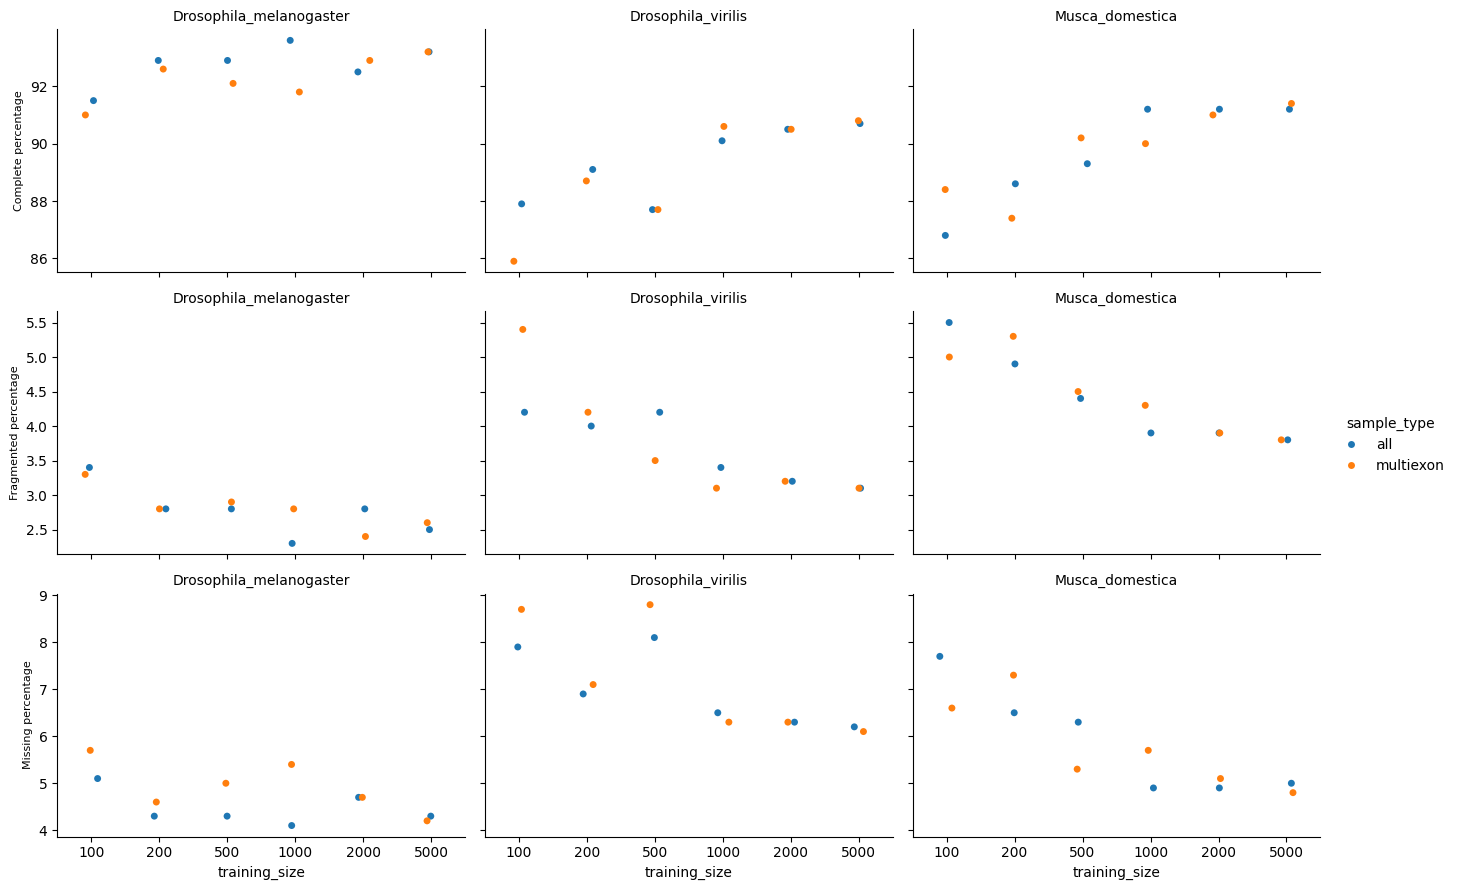

In [15]:
g = sns.catplot(
    data=melted,
    x='training_size',
    y='value',
    hue='sample_type',
    col='Species',
    row='metric',
    order=[100, 200, 500, 1000, 2000, 5000],
    height=3, aspect=1.5,
    sharey='row'
)

g.set_titles("{col_name}")

for (metric,species), ax in g.axes_dict.items():
    ax.set_ylabel(metric, size = 8)

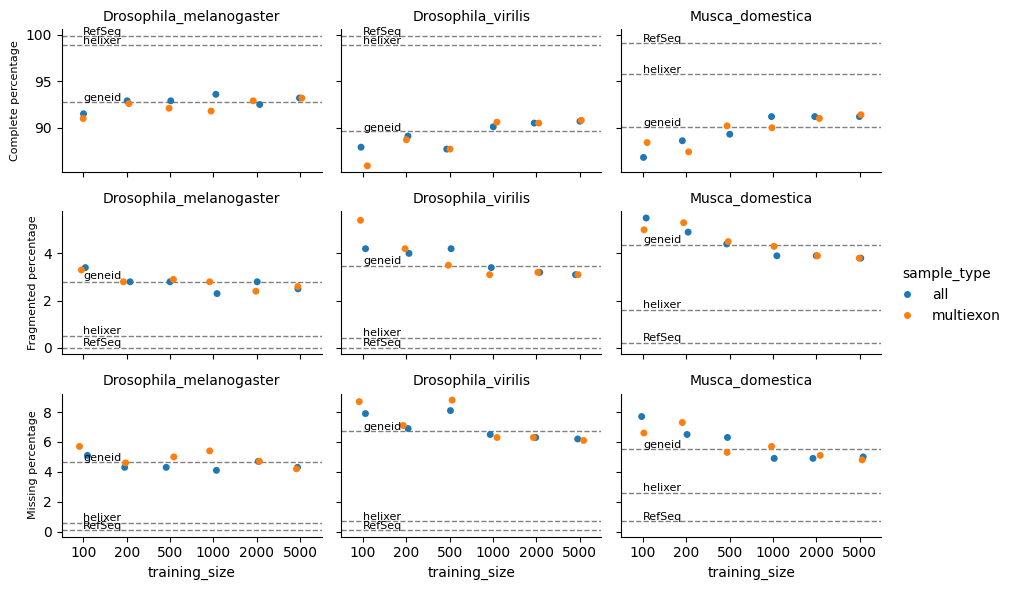

In [16]:
g = sns.catplot(
    data=melted,
    x='training_size',
    y='value',
    hue='sample_type',
    col='Species',
    row='metric',
    order=[100, 200, 500, 1000, 2000, 5000],
    height=2, aspect=1.5,
    sharey='row'
)

g.set_titles("{col_name}")

for (metric,species), ax in g.axes_dict.items():
    ax.set_ylabel(metric, size = 8)
    for program in ['geneid', 'RefSeq', 'helixer']:
        vals = melted.loc[(melted['program'] == program) &
                            (melted['Species'] == species) &
                            (melted['metric'] == metric), 'value']
        median = vals.median()
        ax.axhline(y=median, linestyle='--', linewidth=1, label = program, color = 'gray')
        ax.text(0, median + 0.1, f'{program}', size = 8)

### summary stats

In [4]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [5]:
titration_res_files = ! find ../results/titration_drosophila/*/*/compann/output/summary_stat/ -name 'summary_stats_combined.csv'
musca_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Musca_domestica.7370/output/summary_stat/ -name 'summary_stats_combined.csv'
dmel_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_melanogaster.7227/output/summary_stat/ -name 'summary_stats_combined.csv'
dvir_res_files = ! find /users/rg/fzanarello/projects/compann-nf_RUNS/species/Drosophila_virilis.7244/output/summary_stat/ -name 'summary_stats_combined.csv'

In [6]:
summary_res_files = titration_res_files + musca_res_files + dmel_res_files + dvir_res_files

In [7]:
def get_program(x):
    if 'RefSeq' in x:
        return 'RefSeq'
    if 'helixer' in x:
        return 'helixer'
    if 'augustus' in x:
        return 'augustus'
    if 'geneid':
        return 'geneid'

In [8]:
def get_species(x):
    species = '_'.join(x.split('_')[1:3])
    return species

In [9]:
def get_sample_size(x):
    if 'geneid' in x:
        sample_size = x.split('_')[0].replace('geneidsample','')
        if 'multiexon' in sample_size:
            sample_size = sample_size.replace('multiexon','')
            return sample_size
        else:
            sample_size = sample_size.replace('all','')
            return sample_size
    else:
        return np.nan

In [10]:
def get_sample_type(x):
    if 'multiexon' in x:
        return 'multiexon'
    if 'all' in x:
        return 'all'
    else:
        return np.nan

In [11]:
summary_df = pd.DataFrame()
for f in summary_res_files:   
    tmp_df = pd.read_csv(f)
    
    tmp_df['program'] = tmp_df['File Name'].map(get_program)
    tmp_df['Species'] = tmp_df['File Name'].map(get_species)
    tmp_df['training_size'] = tmp_df['File Name'].map(get_sample_size)
    tmp_df['sample_type'] = tmp_df['File Name'].map(get_sample_type)
    
    summary_df = pd.concat([summary_df, tmp_df], axis=0)

summary_df = summary_df.drop_duplicates().reset_index()

In [12]:
basic_df = summary_df[(summary_df['Type'].isin(['cds','gene'])) & (summary_df['Full/200+'] == '200+')]

In [13]:
basic_df

,index,File Name,Full/200+,Type,Number,Size total (kb),Size mean (bp),program,Species,training_size,sample_type
26,26,geneidsample1000all_Drosophila_melanogaster_72...,200+,cds,73473,25499.07,347.05,geneid,Drosophila_melanogaster,1000,all
27,27,geneidsample1000all_Drosophila_melanogaster_72...,200+,gene,18456,73395.91,3976.80,geneid,Drosophila_melanogaster,1000,all
30,30,RefSeq_Drosophila_melanogaster_7227_longisofor...,200+,cds,55264,22477.21,406.72,RefSeq,Drosophila_melanogaster,NaN,NaN
31,31,RefSeq_Drosophila_melanogaster_7227_longisofor...,200+,gene,16507,95288.76,5772.63,RefSeq,Drosophila_melanogaster,NaN,NaN
39,26,geneidsample1000multiexon_Drosophila_melanogas...,200+,cds,57963,23438.04,404.36,geneid,Drosophila_melanogaster,1000,multiexon
...,...,...,...,...,...,...,...,...,...,...,...
503,46,geneidDMEL_Drosophila_virilis_7244_longisoform...,200+,gene,16307,100269.10,6148.84,geneid,Drosophila_virilis,geneidDMEL,NaN
506,49,geneidSELF_Drosophila_virilis_7244_longisoform...,200+,cds,61633,25495.10,413.66,geneid,Drosophila_virilis,geneidSELF,NaN
507,50,geneidSELF_Drosophila_virilis_7244_longisoform...,200+,gene,16179,100213.77,6194.06,geneid,Drosophila_virilis,geneidSELF,NaN
510,57,helixerGPU_Drosophila_virilis_7244_longisoform...,200+,cds,60808,23577.04,387.73,helixer,Drosophila_virilis,NaN,NaN


In [14]:
melt_df = basic_df.melt(id_vars= ['File Name','Type','program','Species', 'training_size','sample_type'],
                          value_vars= ['Number','Size total (kb)','Size mean (bp)'])

In [15]:
melt_df

,File Name,Type,program,Species,training_size,sample_type,variable,value
0,geneidsample1000all_Drosophila_melanogaster_72...,cds,geneid,Drosophila_melanogaster,1000,all,Number,73473.00
1,geneidsample1000all_Drosophila_melanogaster_72...,gene,geneid,Drosophila_melanogaster,1000,all,Number,18456.00
2,RefSeq_Drosophila_melanogaster_7227_longisofor...,cds,RefSeq,Drosophila_melanogaster,NaN,NaN,Number,55264.00
3,RefSeq_Drosophila_melanogaster_7227_longisofor...,gene,RefSeq,Drosophila_melanogaster,NaN,NaN,Number,16507.00
4,geneidsample1000multiexon_Drosophila_melanogas...,cds,geneid,Drosophila_melanogaster,1000,multiexon,Number,57963.00
...,...,...,...,...,...,...,...,...
301,geneidDMEL_Drosophila_virilis_7244_longisoform...,gene,geneid,Drosophila_virilis,geneidDMEL,NaN,Size mean (bp),6148.84
302,geneidSELF_Drosophila_virilis_7244_longisoform...,cds,geneid,Drosophila_virilis,geneidSELF,NaN,Size mean (bp),413.66
303,geneidSELF_Drosophila_virilis_7244_longisoform...,gene,geneid,Drosophila_virilis,geneidSELF,NaN,Size mean (bp),6194.06
304,helixerGPU_Drosophila_virilis_7244_longisoform...,cds,helixer,Drosophila_virilis,NaN,NaN,Size mean (bp),387.73


Text(0.5, 0.98, 'Summaries statistics are in the same range regardless training size')

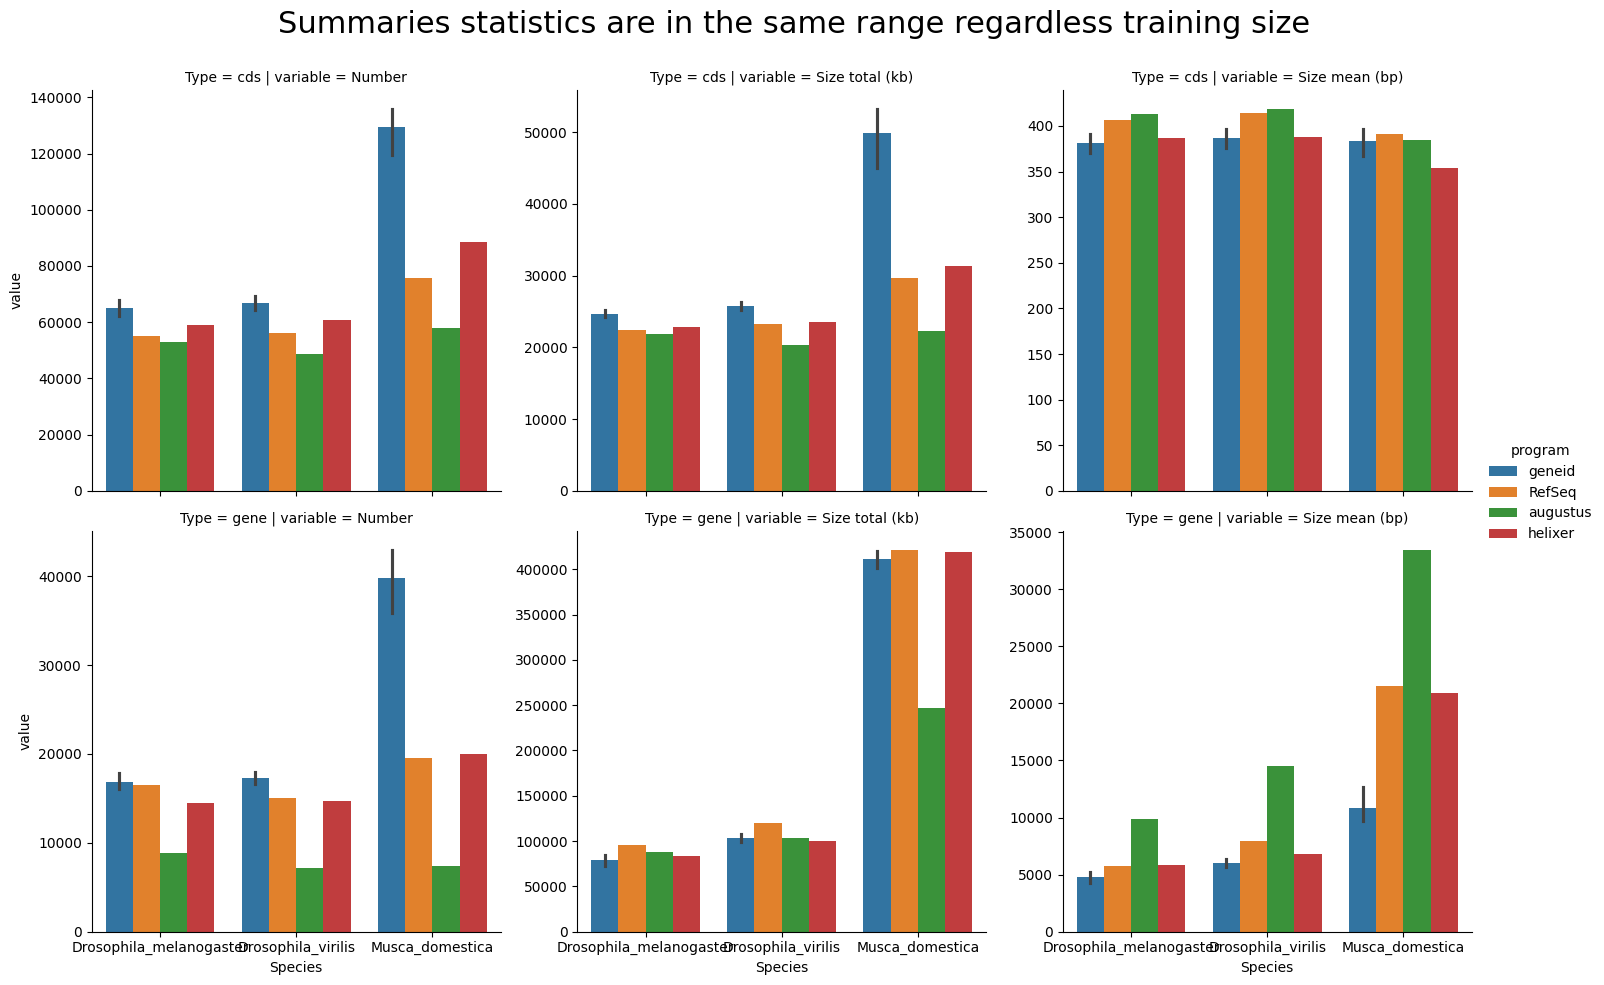

In [28]:
a = sns.catplot(data = melt_df,
            x = 'Species',
            y = 'value',
            hue = 'program',
            row = 'Type', 
            col = 'variable',
            sharey = False,
            kind = 'bar'
            )

a.fig.subplots_adjust(top=0.9)
a.fig.suptitle('Summaries statistics are in the same range regardless training size', size = 22)

Text(0.5, 0.98, 'Summaries statistics stabilize after 1k example genes')

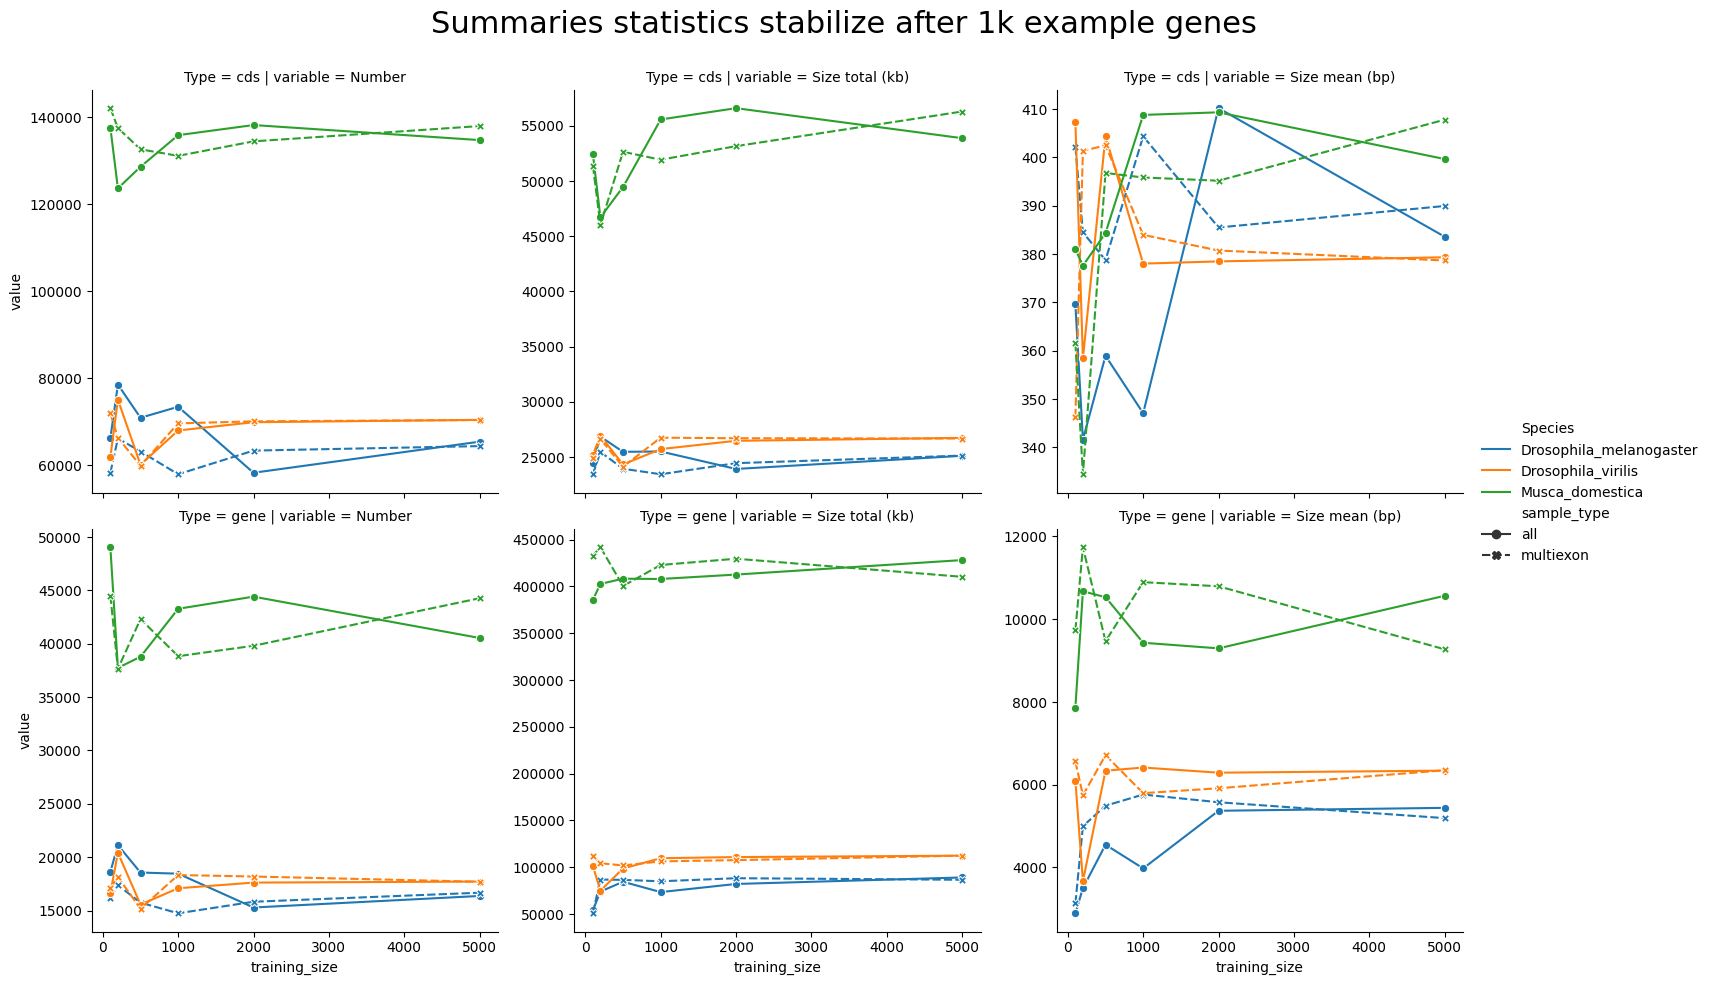

In [49]:
a = sns.relplot(data = melt_df,
            x = pd.to_numeric(melt_df['training_size'], errors='coerce'),
            y = 'value',
            hue = 'Species',
            style = 'sample_type',
            row = 'Type', 
            col = 'variable',
            kind = 'line',
            markers=True,
            facet_kws={'sharey': False, 'sharex': True})

a.fig.subplots_adjust(top=0.9)
a.fig.suptitle('Summaries statistics stabilize after 1k example genes', size = 22)

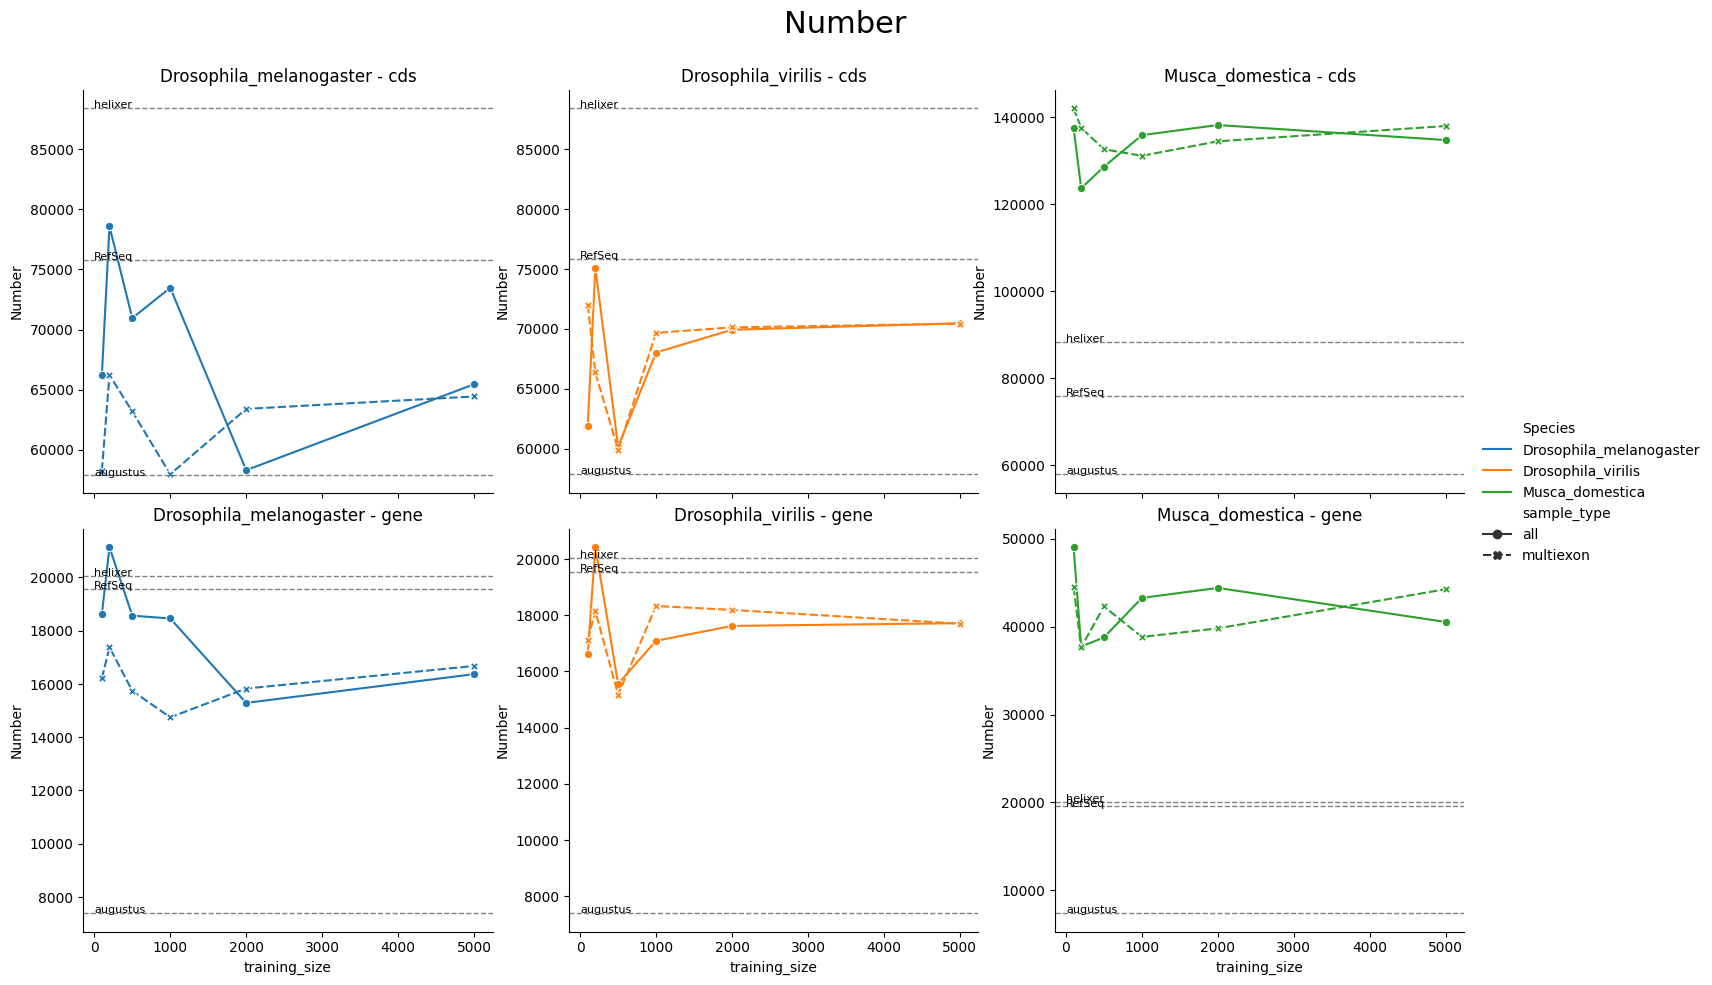

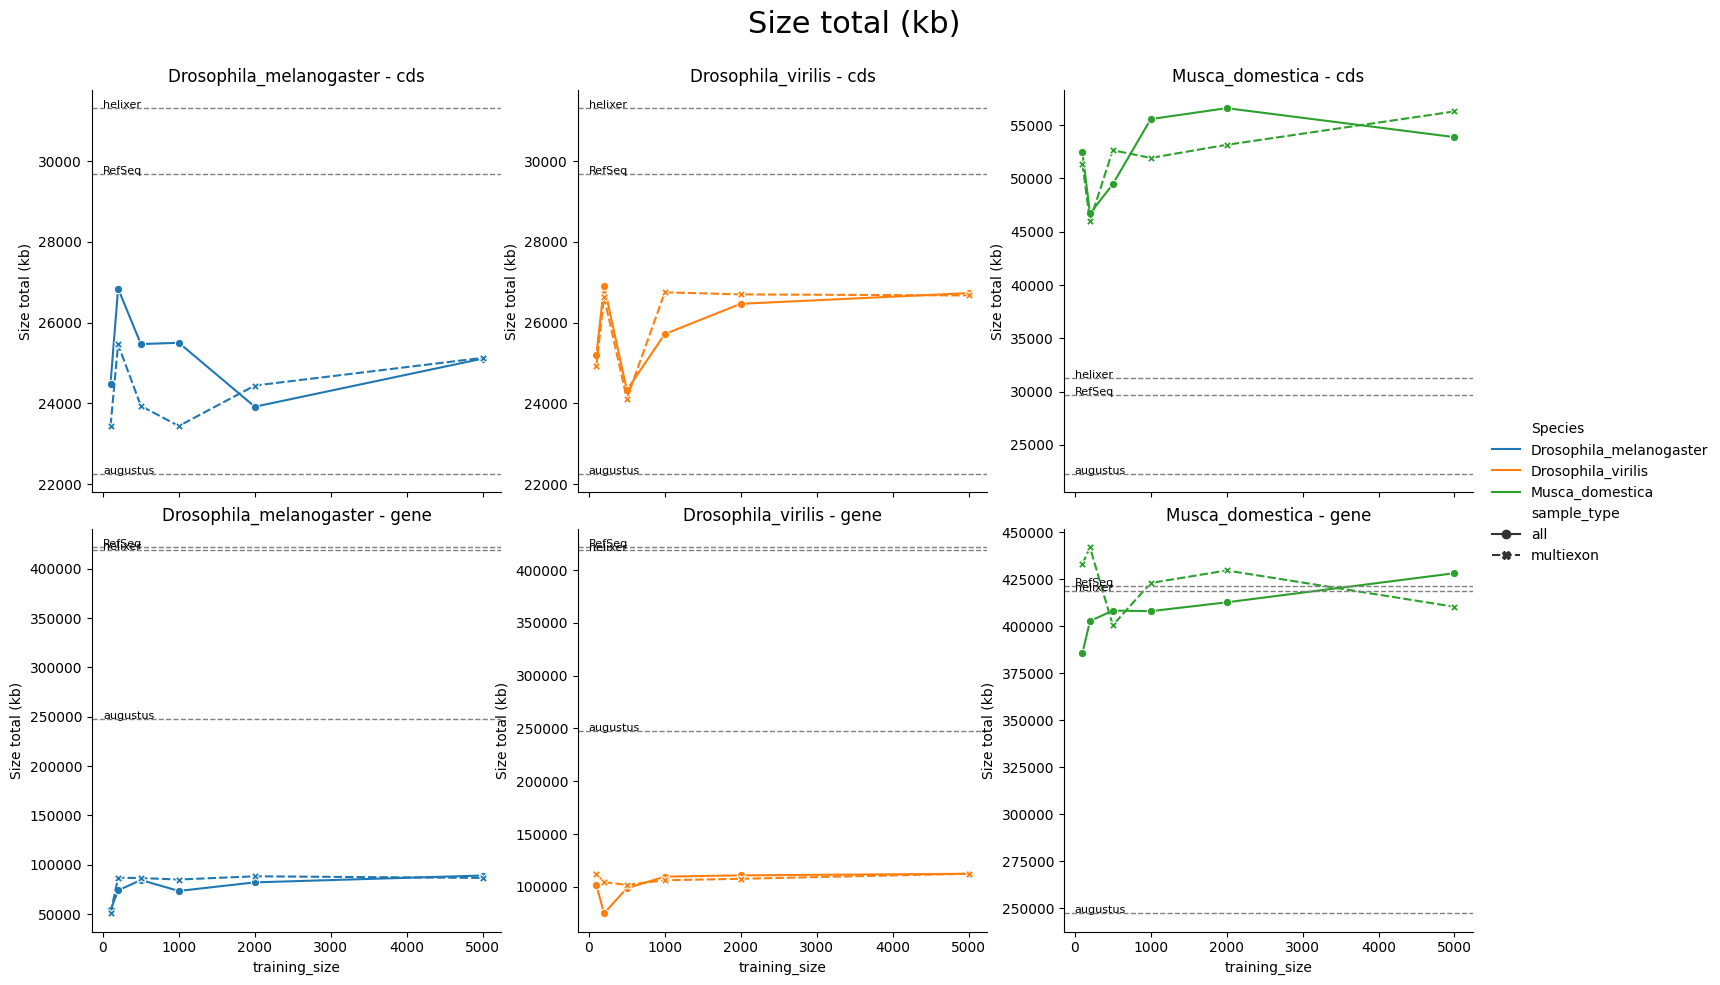

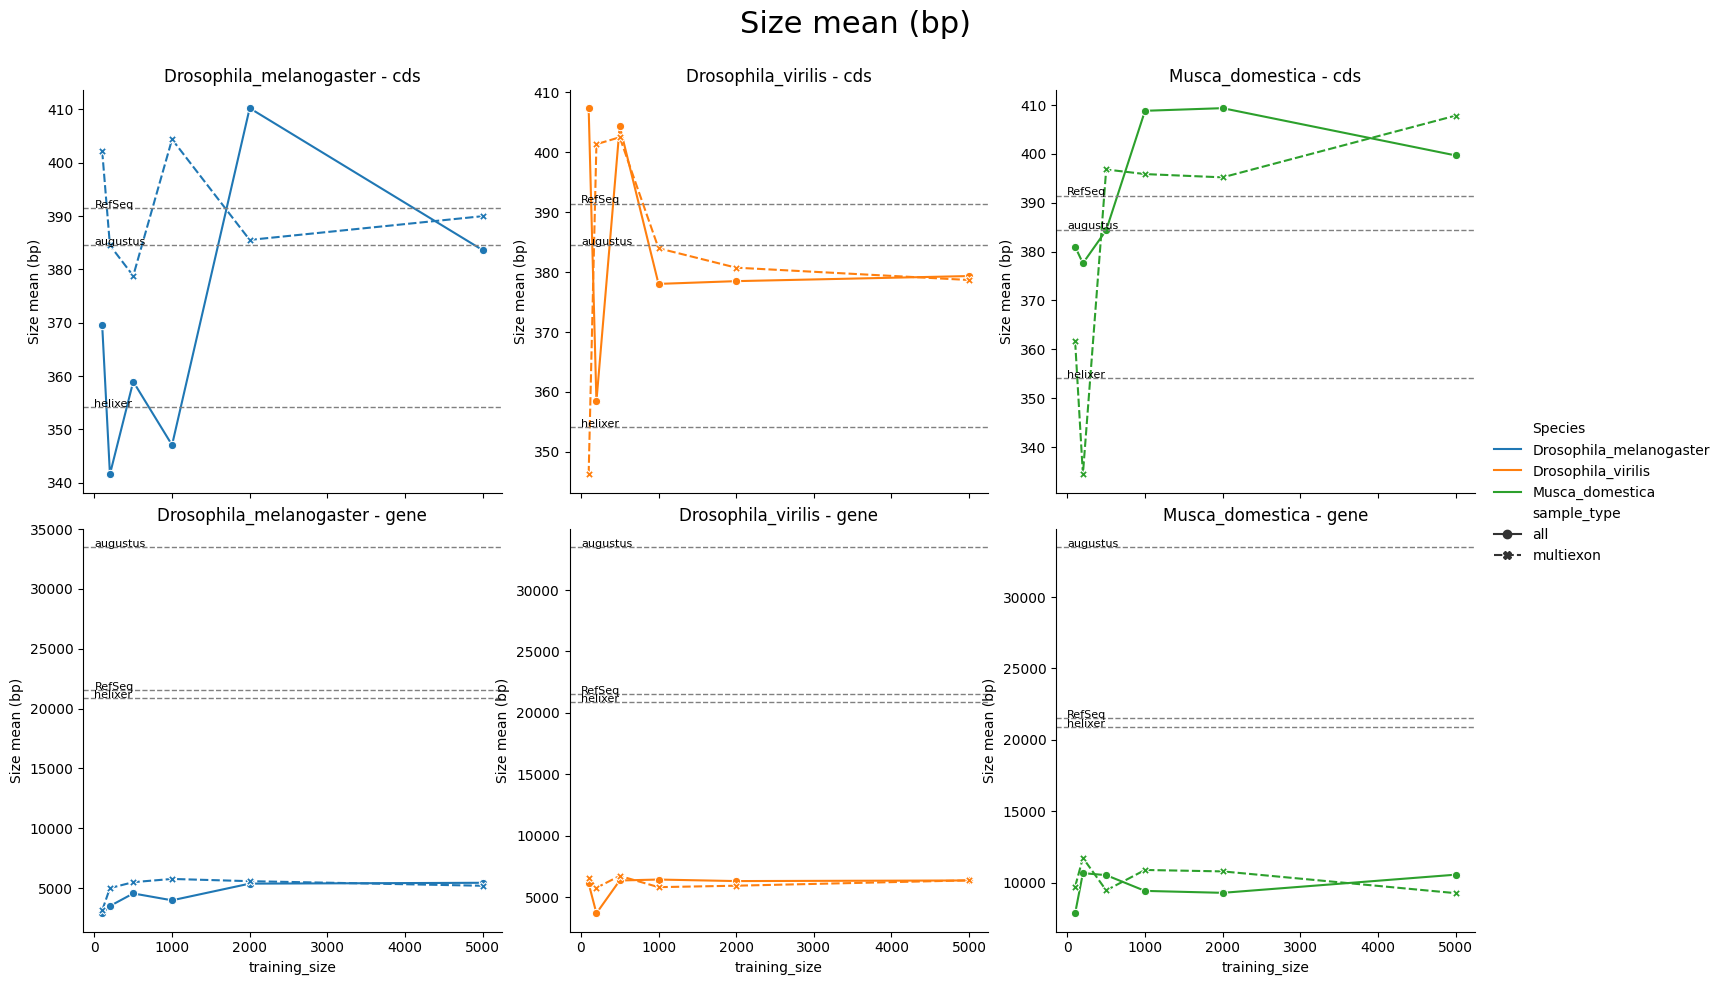

In [71]:
for variable in melt_df.variable.unique():

    a = sns.relplot(data = melt_df[melt_df.variable == variable],
                x = pd.to_numeric(melt_df['training_size'], errors='coerce'),
                y = 'value',
                hue = 'Species',
                style = 'sample_type',
                row = 'Type', 
                col = 'Species',
                kind = 'line',
                markers=True,
                facet_kws={'sharey': False, 'sharex': True})
    a.fig.subplots_adjust(top=0.9)
    a.fig.suptitle(f'{variable}', size = 22)

    for (Type, Species), ax in a.axes_dict.items():
        for program in ['RefSeq', 'helixer','augustus']:
            ax.set_title(f'{Species} - {Type}')
            ax.set_ylabel(variable)
            vals = melt_df.loc[(melt_df['program'] == program) &
                              (melt_df['Species'] == species) &
                              (melt_df['Type'] == Type) &
                              (melt_df['variable'] == variable), 'value']
            median = vals.median()
            ax.axhline(y=median, linestyle='--', linewidth=1, label = program, color = 'gray')
            ax.text(0, median + 0.1, f'{program}', size = 8)


### models structure

In [83]:
metrics = ['base_level_Se', 'base_level_Pr',
           'exon_level_Se', 'exon_level_Pr',
           'locus_level_Se', 'locus_level_Pr']

acc_df = pd.DataFrame()

for s in species:
    gffcomapre_df = pd.read_csv(f'../../compann-nf_RUNS/species/{s}/output/gffcompare/summary/combined_gffcompare_extend.tsv')
    original_column = gffcomapre_df.columns.drop('comparison')
    gffcomapre_df['val'] = gffcomapre_df[original_column].bfill(axis=1).iloc[:, 0]
    gffcomapre_df = gffcomapre_df.drop(original_column, axis=1)
    
    gffcomapre_df['metric'] = gffcomapre_df.comparison.map(lambda x : x.split('-')[-1])
    gffcomapre_df['measure'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[-1])
    gffcomapre_df['level'] = gffcomapre_df['metric'].map(lambda x : x.split('_')[0])
    
    gffcomapre_df['reference'] = gffcomapre_df.comparison.map(lambda x : x.split('_')[0])
    gffcomapre_df['query'] = gffcomapre_df.comparison.map(lambda x : x.split('_vs_')[1].split('_')[0])
    gffcomapre_df['Species'] = gffcomapre_df.comparison.map(lambda x : '_'.join(x.split('_vs_')[0].split('_')[1:-1]))
    gffcomapre_df['Genus'] = gffcomapre_df.Species.map(lambda x : x.split('_')[0])
    
    gffcomapre_df = gffcomapre_df[(gffcomapre_df['reference'] == 'RefSeq') & (gffcomapre_df['query'] != 'RefSeq')]
    gffcomapre_df = gffcomapre_df[gffcomapre_df.metric.isin(metrics)]
    gffcomapre_df.val = pd.to_numeric(gffcomapre_df.val)
    
    acc_df = pd.concat([acc_df, gffcomapre_df], axis=0)

acc_df = acc_df.reset_index()

In [11]:
acc_df

,index,comparison,val,metric,measure,level,reference,query,Species,Genus
0,2,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,70.4,base_level_Se,Se,base,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
1,3,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,71.2,base_level_Pr,Pr,base,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
2,4,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,56.1,exon_level_Se,Se,exon,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
3,5,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,53.3,exon_level_Pr,Pr,exon,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
4,8,RefSeq_Drosophila_ananassae_7217_vs_geneidDMEL...,33.4,locus_level_Se,Se,locus,RefSeq,geneidDMEL,Drosophila_ananassae,Drosophila
...,...,...,...,...,...,...,...,...,...,...
277,122,RefSeq_Musca_domestica_7370_vs_augustus_Musca_...,83.9,base_level_Pr,Pr,base,RefSeq,augustus,Musca_domestica,Musca
278,123,RefSeq_Musca_domestica_7370_vs_augustus_Musca_...,40.2,exon_level_Se,Se,exon,RefSeq,augustus,Musca_domestica,Musca
279,124,RefSeq_Musca_domestica_7370_vs_augustus_Musca_...,52.3,exon_level_Pr,Pr,exon,RefSeq,augustus,Musca_domestica,Musca
280,127,RefSeq_Musca_domestica_7370_vs_augustus_Musca_...,5.8,locus_level_Se,Se,locus,RefSeq,augustus,Musca_domestica,Musca


In [12]:
def calculate_f1(precision, recall):
    """Calculate the F1 score given precision and recall."""
    if precision + recall == 0:
        return 0
    return round(2 * (precision * recall) / (precision + recall),1)

def compute_f1_scores(df):
    """
    Compute F1 scores for base, exon and locus levels from a DataFrame, grouping by Species, Genus, and Query.

    Parameters:
    df (pd.DataFrame): DataFrame with columns ['metric', 'val', 'Species', 'Genus', 'query'].

    Returns:
    pd.DataFrame: A new DataFrame with F1 scores computed for each species-query combination.
    """
    
    # Pivot the data for easier access
    pivot_df = df.pivot(index=["Species", "Genus", "query"], columns="metric", values="val").reset_index()

    # Calculate F1 scores
    pivot_df["base_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("base_level_Pr", 0), row.get("base_level_Se", 0)), axis=1
    )
    pivot_df["exon_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("exon_level_Pr", 0), row.get("exon_level_Se", 0)), axis=1
    )
    pivot_df["locus_level_F1"] = pivot_df.apply(
        lambda row: calculate_f1(row.get("locus_level_Pr", 0), row.get("locus_level_Se", 0)), axis=1
    )

    result_df = pivot_df.melt(id_vars=['Species','Genus','query'],
           value_vars=['base_level_Pr','base_level_Se','exon_level_Pr',
                       'exon_level_Se','locus_level_Pr','locus_level_Se',
                       'base_level_F1','exon_level_F1','locus_level_F1'])
    
    result_df['measure'] = result_df['metric'].map(lambda x : x.split('_')[-1])
    result_df['level'] = result_df['metric'].map(lambda x : x.split('_')[0])
    
    return result_df

In [13]:
f1_df = compute_f1_scores(acc_df)

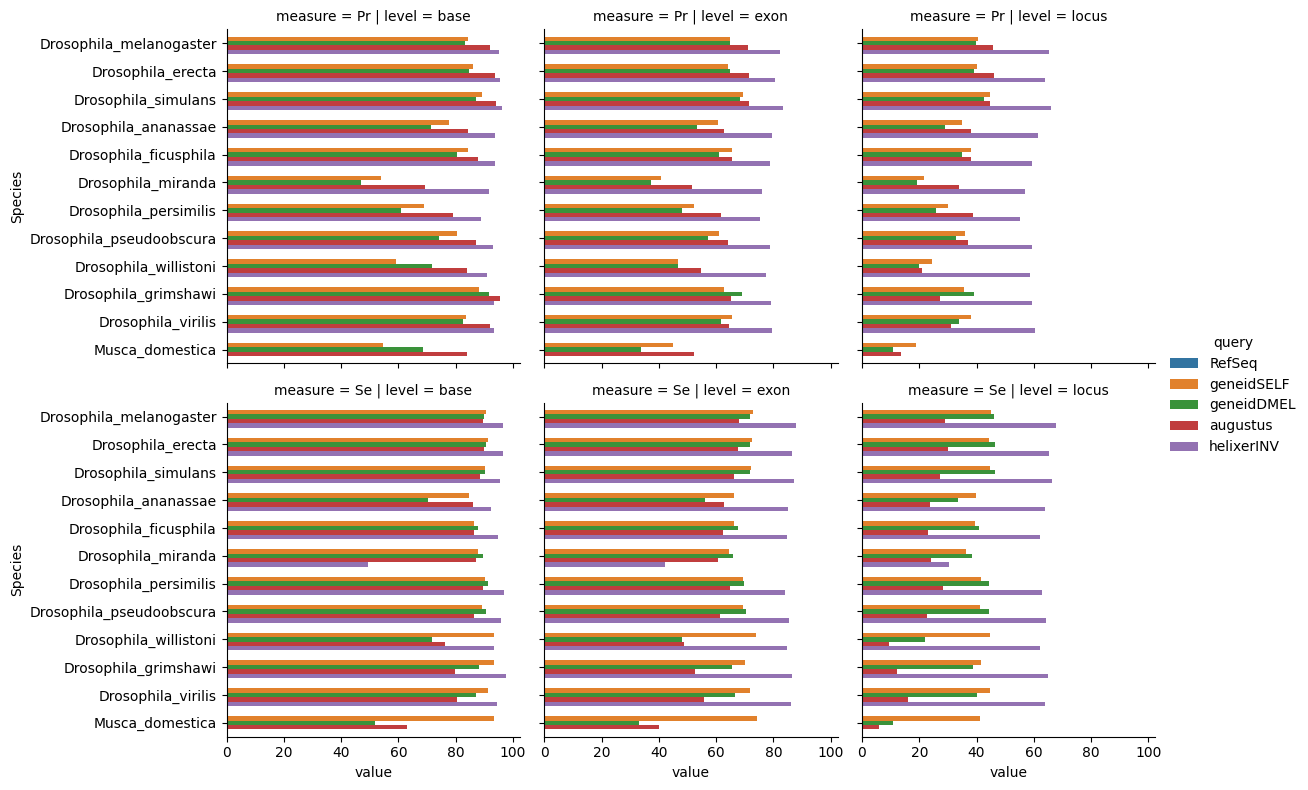

In [14]:
sns.catplot(data = f1_df[f1_df.measure.isin(['Pr','Se'])] ,
            y = 'Species',
            x = 'value',
            col = 'level',
            kind='bar',
            row = 'measure',
            order = species_order,
            hue='query',
            height=4, aspect=1,
            hue_order = ['RefSeq', 'geneidSELF','geneidDMEL', 'augustus', 'helixerINV'])
plt.show()

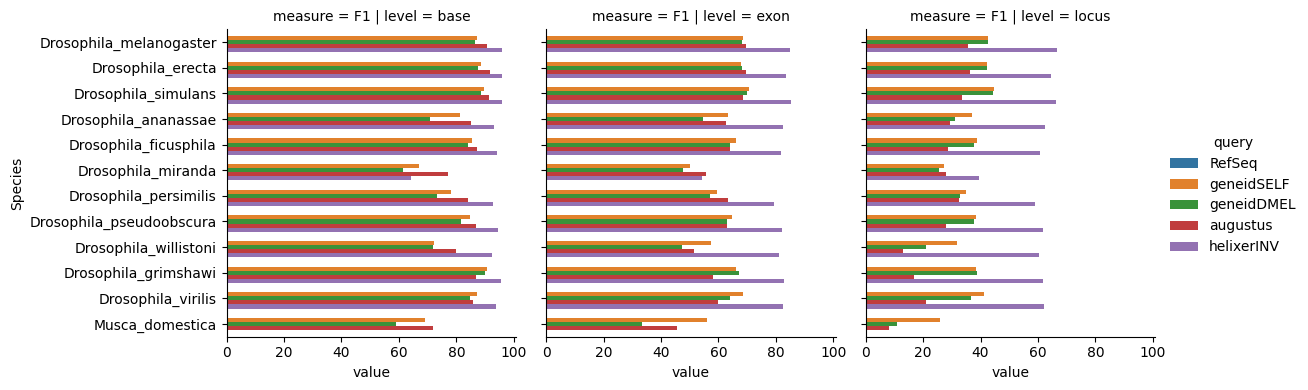

In [15]:
sns.catplot(data = f1_df[f1_df.measure == 'F1'] ,
            y = 'Species',
            x = 'value',
            col = 'level',
            kind='bar',
            row = 'measure',
            order = species_order,
            hue='query',
            height=4, aspect=1,
            hue_order = ['RefSeq', 'geneidSELF','geneidDMEL', 'augustus', 'helixerINV'])
plt.show()